
# 🐘 Working with Images in OpenCV (Jupyter Notebook)

In this notebook, we will perform some basic operations with images using **OpenCV (cv2)** and **Matplotlib** for visualization.

---

### 📌 Why Matplotlib instead of cv2.imshow()?
- `cv2.imshow()` opens a separate GUI window, which often causes issues in Jupyter Notebook.  
- Instead, we use **Matplotlib** (`plt.imshow`) to display images **inline** inside the notebook.  
- OpenCV loads images in **BGR format**, while Matplotlib expects **RGB format**, so we need a conversion step:
  `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`

---

### 📌 Key Functions Used:
- **cv2.imread(path)** → Reads the image from the given path.  
- **cv2.cvtColor(image, cv2.COLOR_BGR2RGB)** → Converts BGR to RGB for correct display.  
- **plt.imshow(image)** → Displays the image inline in the notebook.  
- **image.shape** → Returns image dimensions as `(height, width, channels)`.  
- **cv2.imwrite(output_path, image)** → Saves the image to disk.

---

### 🔹 Workflow:
1. Load the input image (`elephant.jpg`).  
2. Convert from BGR to RGB for correct display.  
3. Display the image inline in Jupyter Notebook using Matplotlib.  
4. Print its height and width in pixels.  
5. Save it in PNG format (`output.png`).  

This is the **first step in Computer Vision pipelines** and serves as the foundation for tasks like **image preprocessing, feature extraction, and deep learning applications**.




In [1]:
# -----------------------------------------
# Basic Image Operations with OpenCV in Jupyter
# -----------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt  # for inline display

In [3]:
# Read the input image
image = cv2.imread("elephant.jpg")
image

array([[[128, 146, 163],
        [128, 146, 163],
        [129, 147, 164],
        ...,
        [ 78,  83,  86],
        [ 77,  82,  85],
        [ 77,  82,  85]],

       [[128, 146, 163],
        [129, 147, 164],
        [129, 147, 164],
        ...,
        [ 77,  82,  85],
        [ 77,  82,  85],
        [ 76,  81,  84]],

       [[129, 147, 164],
        [129, 147, 164],
        [130, 148, 165],
        ...,
        [ 77,  82,  85],
        [ 76,  81,  84],
        [ 76,  81,  84]],

       ...,

       [[ 35,  33,  33],
        [ 37,  35,  35],
        [ 39,  37,  37],
        ...,
        [ 57,  52,  53],
        [ 57,  52,  53],
        [ 57,  52,  53]],

       [[ 37,  35,  35],
        [ 38,  36,  36],
        [ 40,  38,  38],
        ...,
        [ 56,  51,  52],
        [ 56,  51,  52],
        [ 56,  51,  52]],

       [[ 37,  35,  35],
        [ 37,  35,  35],
        [ 38,  36,  36],
        ...,
        [ 56,  51,  52],
        [ 56,  51,  52],
        [ 56,  51,  52]]

In [4]:
# Convert BGR (OpenCV default) to RGB (matplotlib expects RGB)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

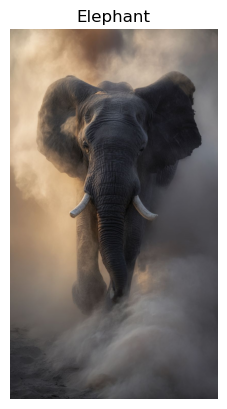

In [5]:
# Display image inline in the notebook
plt.imshow(image_rgb)
plt.axis('off')  # hide axis for better visualization
plt.title("Elephant")
plt.show()

In [6]:
# Print image dimensions
print('Height of Image:', int(image.shape[0]), 'pixels')
print('Width of Image :', int(image.shape[1]), 'pixels')

Height of Image: 1456 pixels
Width of Image : 816 pixels


In [7]:
# Save the image in PNG format
cv2.imwrite('output.png', image)

True

# 🎯 Object Detection Using OpenCV (Color Detection)

In this notebook, we will detect **specific colors (Red, Green, Blue)** from the webcam feed using OpenCV.

---

### 📌 Workflow:
1. Capture live video from the webcam (`cv2.VideoCapture(0)`).
2. Convert each frame from **BGR** (default in OpenCV) to **HSV (Hue, Saturation, Value)**.
   - **Hue** → Represents the color type (red, green, blue, etc.).
   - **Saturation** → Intensity/purity of the color (0 → white, 255 → fully colored).
   - **Value** → Brightness of the color (0 → black, 255 → bright).
3. Define **color ranges** for Red, Green, and Blue in HSV.
4. Create masks to filter out only the selected color from the frame.
5. Show the original frame and the color-detected regions in real-time.
6. Press `Esc (27)` to exit the loop.

---

### 📌 Key Functions:
- **cv2.VideoCapture(0)** → Opens webcam feed.
- **cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)** → Converts BGR image to HSV.
- **cv2.inRange(hsv_frame, lower_bound, upper_bound)** → Creates a mask for a given color range.
- **cv2.bitwise_and(frame, frame, mask=mask)** → Applies the mask to extract only the target color.
- **cv2.imshow(window, image)** → Displays image/video frame in a window.


In [8]:
import cv2
import numpy as np

# Open webcam (0 = default camera, 1 or 2 for external webcams)
cap = cv2.VideoCapture(0)

while True:
    # Capture each frame
    ret, frame = cap.read()
    if not ret:
        break
    
    # Convert frame from BGR to HSV color space
    hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # -------------------------------
    # Define color ranges in HSV
    # -------------------------------
    
    # Red color range (lower and upper)
    lower_red = np.array([0, 120, 70])
    upper_red = np.array([10, 255, 255])
    mask_red = cv2.inRange(hsv_frame, lower_red, upper_red)
    red_result = cv2.bitwise_and(frame, frame, mask=mask_red)
    
    # Green color range
    lower_green = np.array([36, 100, 100])
    upper_green = np.array([86, 255, 255])
    mask_green = cv2.inRange(hsv_frame, lower_green, upper_green)
    green_result = cv2.bitwise_and(frame, frame, mask=mask_green)
    
    # Blue color range
    lower_blue = np.array([94, 80, 2])
    upper_blue = np.array([126, 255, 255])
    mask_blue = cv2.inRange(hsv_frame, lower_blue, upper_blue)
    blue_result = cv2.bitwise_and(frame, frame, mask=mask_blue)
    
    # -------------------------------
    # Display the results
    # -------------------------------
    cv2.imshow("Original Frame", frame)
    cv2.imshow("Red Detection", red_result)
    cv2.imshow("Green Detection", green_result)
    cv2.imshow("Blue Detection", blue_result)
    
    # Exit loop when "Esc" key (27) is pressed
    key = cv2.waitKey(1)
    if key == 27:
        break

# Release the webcam and close all windows
cap.release()
cv2.destroyAllWindows()

# 🔴 Red Color Detection using OpenCV

In this example, we focus only on **detecting red objects** from a webcam feed.

---

### 📌 Workflow:
1. Capture video from webcam (`cv2.VideoCapture(0)`).
2. Convert each frame from **BGR → HSV** (HSV is better for color detection).
3. Define the **red color range** in HSV:
   - Lower bound = `[161, 155, 84]`
   - Upper bound = `[179, 255, 255]`
   *(These values were tested manually to detect red color accurately.)*
4. Create a mask using `cv2.inRange()` → isolates red pixels.
5. Apply the mask on the original frame using `cv2.bitwise_and()`.
6. Display:
   - Original frame
   - Extracted red color frame
7. Press `Esc (27)` to exit.

---

In [10]:
import cv2
import numpy as np

# Open webcam (0 = default camera)
cap = cv2.VideoCapture(0)

while True:
    # Capture each frame
    ret, frame = cap.read()
    if not ret:
        break

    # Convert frame from BGR to HSV
    hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Define Red color range
    low_red = np.array([161, 155, 84])   # Lower HSV bound
    high_red = np.array([179, 255, 255]) # Upper HSV bound

    # Create mask for red color
    red_mask = cv2.inRange(hsv_frame, low_red, high_red)

    # Extract only red regions from the original frame
    red = cv2.bitwise_and(frame, frame, mask=red_mask)

    # -------------------------------
    # Display windows
    # -------------------------------
    cv2.imshow("Original Frame", frame)  # Full camera feed
    cv2.imshow("Red Detection", red)     # Only red color parts

    # Exit when Esc key is pressed
    key = cv2.waitKey(1)
    if key == 27:
        break

# Release camera and close windows
cap.release()
cv2.destroyAllWindows()

# 🔵 Blue Color Detection using OpenCV

This example demonstrates **real-time blue object detection** from a webcam feed using OpenCV.

---

### 📌 Workflow:
1. Capture live video from the webcam (`cv2.VideoCapture(0)`).
2. Convert each frame from **BGR → HSV** color space.
   - HSV makes color detection more robust than BGR.
3. Define the **HSV range for blue**:
   - Lower bound = `[94, 80, 2]`
   - Upper bound = `[126, 255, 255]`
   *(These values can be fine-tuned depending on lighting conditions.)*
4. Create a mask using `cv2.inRange()` to isolate blue pixels.
5. Apply the mask to the original frame using `cv2.bitwise_and()`.
6. Display:
   - Original frame
   - Blue-only frame
7. Press **Esc (27)** to exit the loop.

---

In [11]:
import cv2
import numpy as np

# Open webcam (0 = default camera)
cap = cv2.VideoCapture(0)

while True:    
    # Capture each frame
    ret, frame = cap.read()
    if not ret:
        break
    
    # Convert frame from BGR to HSV
    hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # -------------------------------
    # Blue color detection
    # -------------------------------
    low_blue = np.array([94, 80, 2])     # Lower HSV bound
    high_blue = np.array([126, 255, 255])# Upper HSV bound
    blue_mask = cv2.inRange(hsv_frame, low_blue, high_blue)

    # Extract only blue regions from the original frame
    blue = cv2.bitwise_and(frame, frame, mask=blue_mask)

    # -------------------------------
    # Display the results
    # -------------------------------
    cv2.imshow("Original Frame", frame)   # Webcam feed
    cv2.imshow("Blue Detection", blue)    # Only blue parts visible
    
    # Exit on Esc key
    key = cv2.waitKey(1)
    if key == 27:
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

# 🟢 Green Color Detection using OpenCV

This example demonstrates **real-time green object detection** from a webcam feed using OpenCV.

---

### 📌 Workflow:
1. Capture video from webcam (`cv2.VideoCapture(0)`).
2. Convert each frame from **BGR → HSV**.
   - HSV makes color detection more reliable than BGR since it separates **color info (Hue)** from **brightness (Value)**.
3. Define the **HSV range for green**:
   - Lower bound = `[40, 100, 100]`
   - Upper bound = `[102, 255, 255]`
   *(These values can be tuned depending on lighting conditions.)*
4. Create a mask using `cv2.inRange()` to isolate green pixels.
5. Extract the green regions using `cv2.bitwise_and()`.
6. Display:
   - Original frame
   - Green-only frame
7. Press **Esc (27)** to exit.

---

In [12]:
import cv2
import numpy as np

# Open webcam (0 = default camera)
cap = cv2.VideoCapture(0)

while True:
    # Capture each frame
    ret, frame = cap.read()
    if not ret:
        break
    
    # Convert frame from BGR to HSV
    hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # -------------------------------
    # Green color detection
    # -------------------------------
    low_green = np.array([40, 100, 100])    # Lower HSV bound
    high_green = np.array([102, 255, 255])  # Upper HSV bound
    
    # Create mask for green
    green_mask = cv2.inRange(hsv_frame, low_green, high_green)
    
    # Extract only green regions
    green = cv2.bitwise_and(frame, frame, mask=green_mask)

    # -------------------------------
    # Display the results
    # -------------------------------
    cv2.imshow("Original Frame", frame)   # Webcam feed
    cv2.imshow("Green Detection", green)  # Only green parts visible
    
    # Exit on Esc key
    key = cv2.waitKey(1)
    if key == 27:
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

# 🎨 Detect Every Color Except White using OpenCV

This script shows how to filter out **all colors except white** from a webcam feed.

---

### 📌 Workflow:
1. Capture video from webcam.
2. Convert frame from **BGR → HSV**.
3. Define HSV thresholds:
   - Hue range: [0, 179] → covers all hues.
   - Saturation min = 42 → excludes very low saturation (gray/white areas).
   - Value range: [0, 255] → keeps brightness levels.
   Thus, anything close to white (low saturation) will be excluded.
4. Create a mask with `cv2.inRange()`.
5. Extract everything except white using `cv2.bitwise_and()`.
6. Display:
   - Original Frame
   - Filtered Result (all colors except white)

Press **Esc (27)** to exit.

In [13]:
import cv2
import numpy as np

# Open webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Convert BGR → HSV
    hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # -------------------------------
    # Mask for every color except white
    # -------------------------------
    low = np.array([0, 42, 0])    # Avoid very low saturation (near-white)
    high = np.array([179, 255, 255])
    
    mask = cv2.inRange(hsv_frame, low, high)
    result = cv2.bitwise_and(frame, frame, mask=mask)

    # -------------------------------
    # Display the outputs
    # -------------------------------
    cv2.imshow("Original Frame", frame) 
    cv2.imshow("All Colors Except White", result)
    
    # Exit on Esc key
    key = cv2.waitKey(1)
    if key == 27:
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

# 🎨 Color Detection with OpenCV (Red, Green, Blue)

In this example, we detect specific colors (Red, Green, Blue) from a webcam feed using **OpenCV** and the **HSV color space**.

---

### 📌 Why HSV instead of BGR?
- **BGR**: OpenCV loads images in Blue, Green, Red format, but detecting colors is tricky because brightness changes can affect the result.
- **HSV (Hue, Saturation, Value)**:
  - **Hue** → Defines the type of color (red, green, blue, etc.).
  - **Saturation** → Intensity of the color (0 → white/gray, 255 → pure color).
  - **Value** → Brightness (0 → black, 255 → fully bright).
- Using HSV makes it easier to isolate specific colors.

---

### 📌 Workflow:
1. Capture live video with `cv2.VideoCapture(0)`.
2. Convert each frame from **BGR → HSV**.
3. Define lower and upper HSV ranges for **Red, Green, and Blue**.
4. Create a mask for each color with `cv2.inRange()`.
5. Extract the colored region using `cv2.bitwise_and()`.
6. Display:
   - Original frame
   - Red-only, Green-only, Blue-only frames
   - Combined result for "everything except white"
7. Press `Esc (27)` to exit.

---


In [9]:
import cv2
import numpy as np

# Start capturing from webcam (0 = default camera)
cap = cv2.VideoCapture(0)

while True:
    # Read each frame from the webcam
    ret, frame = cap.read()
    if not ret:
        break
    
    # Convert frame from BGR to HSV
    hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # -------------------------------
    # Define color ranges (HSV format)
    # -------------------------------

    # Red color range
    low_red = np.array([161, 155, 84])   # tested lower bound
    high_red = np.array([179, 255, 255]) # tested upper bound
    red_mask = cv2.inRange(hsv_frame, low_red, high_red)
    red = cv2.bitwise_and(frame, frame, mask=red_mask)

    # Blue color range
    low_blue = np.array([94, 80, 2])
    high_blue = np.array([126, 255, 255])
    blue_mask = cv2.inRange(hsv_frame, low_blue, high_blue)
    blue = cv2.bitwise_and(frame, frame, mask=blue_mask)

    # Green color range
    low_green = np.array([40, 100, 100])
    high_green = np.array([102, 255, 255])
    green_mask = cv2.inRange(hsv_frame, low_green, high_green)
    green = cv2.bitwise_and(frame, frame, mask=green_mask)

    # Everything except white (broad mask)
    low = np.array([0, 42, 0])
    high = np.array([179, 255, 255])
    mask = cv2.inRange(hsv_frame, low, high)
    result = cv2.bitwise_and(frame, frame, mask=mask)

    # -------------------------------
    # Display all frames
    # -------------------------------
    cv2.imshow("Original Frame", frame)
    cv2.imshow("Red Detection", red)
    cv2.imshow("Blue Detection", blue)
    cv2.imshow("Green Detection", green)
    cv2.imshow("Result (Everything except white)", result)

    # Press Esc (27) to break loop
    key = cv2.waitKey(1)
    if key == 27:
        break

# Release resources
cap.release()
cv2.destroyAllWindows()


# 🖐️ Gesture Control with MediaPipe, OpenCV & PyAutoGUI

This script lets you **control your keyboard arrows (⬆️⬇️⬅️➡️)** 
by swiping your **index finger** in front of the webcam.

---

### 📌 Workflow:
1. Capture video from webcam (OpenCV).
2. Detect **hand landmarks** using MediaPipe Hands.
3. Track **index fingertip position** (`landmark[8]`).
4. Compare new vs. old positions:
   - Large horizontal movement → LEFT / RIGHT
   - Large vertical movement → UP / DOWN
   - (Horizontal swipe direction is inverted in this version.)
5. Trigger **keyboard arrow key presses** with PyAutoGUI.
6. Display video with landmarks + detected gesture label.


In [ ]:
import cv2
import mediapipe as mp
import pyautogui
import time

# ---------------------------------------------
# Setup MediaPipe Hands & Drawing Utils
# ---------------------------------------------
mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

class IndexFingerSwipeTracker:
    """
    Tracks index finger movements and detects swipe gestures.
    """
    def __init__(self):
        # Use MediaPipe Hands (only 1 hand tracked for simplicity)
        self.hands = mp_hands.Hands(min_detection_confidence=0.7, max_num_hands=1)
        self.last_pos = None  # Stores last fingertip position (x, y)

        # Sensitivity thresholds
        self.swipe_threshold_x = 0.05   # Horizontal swipe threshold
        self.swipe_threshold_y = 0.05   # Vertical swipe threshold

        # Cooldown to avoid rapid multiple triggers
        self.cooldown = 0.5  
        self.last_trigger = time.time()

    def detect_gesture(self, frame):
        """
        Detects swipes (up, down, left, right) from index finger movement.
        """
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = self.hands.process(frame_rgb)

        gesture = None
        hand_landmarks = None

        if results.multi_hand_landmarks:
            # Track the first detected hand
            hand_landmarks = results.multi_hand_landmarks[0]

            # Index fingertip landmark
            index_tip = hand_landmarks.landmark[8]
            current_pos = (index_tip.x, index_tip.y)

            if self.last_pos:
                dx = current_pos[0] - self.last_pos[0]
                dy = current_pos[1] - self.last_pos[1]

                # Detect horizontal swipe
                if abs(dx) > self.swipe_threshold_x and abs(dx) > abs(dy):
                    gesture = "left" if dx > 0 else "right"  # Inverted here

                # Detect vertical swipe
                elif abs(dy) > self.swipe_threshold_y and abs(dy) > abs(dx):
                    gesture = "down" if dy > 0 else "up"

            self.last_pos = current_pos

        else:
            self.last_pos = None  # Reset if no hand detected

        return gesture, hand_landmarks


def trigger_key(gesture, tracker):
    """
    Maps gestures to keyboard arrow key presses (via PyAutoGUI).
    """
    now = time.time()
    if gesture and (now - tracker.last_trigger > tracker.cooldown):
        if gesture == "left":
            pyautogui.press("left")
        elif gesture == "right":
            pyautogui.press("right")
        elif gesture == "up":
            pyautogui.press("up")
        elif gesture == "down":
            pyautogui.press("down")
        tracker.last_trigger = now


def main():
    cap = cv2.VideoCapture(0)  # Open webcam
    tracker = IndexFingerSwipeTracker()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Detect gestures
        gesture, landmarks = tracker.detect_gesture(frame)

        # Draw landmarks if hand detected
        if landmarks:
            mp_drawing.draw_landmarks(
                frame, landmarks, mp_hands.HAND_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=4),
                mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2)
            )

        # Show detected gesture on screen
        if gesture:
            cv2.putText(frame, gesture.upper(), (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
            trigger_key(gesture, tracker)

        # Display video feed
        cv2.imshow("Index Finger Swipe Controls (Inverted L/R)", frame)

        # Exit on ESC
        if cv2.waitKey(1) & 0xFF == 27:
            break

    cap.release()
    cv2.destroyAllWindows()


if __name__ == "__main__":
    main()